#0 CSV-File einlesen

In [ ]:
import pandas as pd

# URL der CSV-Datei auf GitHub
# url = 'https://github.com/nesasad/BINA_PV_Anlagen/blob/main/Data/Rohdaten-Tarife-Standard-Produkt.csv'

url = 'https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/Rohdaten-Tarife-Standard-Produkt.csv'

# Lese die CSV-Datei in ein Pandas DataFrame ein
df = pd.read_csv(url)

# Zeige die ersten paar Zeilen des DataFrames zur Bestätigung an
df.head()

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
0,CHE-105.981.944,AEW Energie AG,C1,4172,Münchwilen (AG),AG,26.594,11.4,0.689,11.53,2.3,54.0
1,CHE-105.981.944,AEW Energie AG,C1,4253,Magden,AG,26.594,11.4,0.689,11.53,2.3,54.0
2,CHE-105.981.944,AEW Energie AG,C1,4106,Mönthal,AG,26.555,11.4,0.650,11.53,2.3,54.0
3,CHE-105.981.944,AEW Energie AG,C1,4068,Hägglingen,AG,26.594,11.4,0.689,11.53,2.3,54.0
4,CHE-105.981.944,AEW Energie AG,C1,4258,Rheinfelden,AG,26.594,11.4,0.689,11.53,2.3,54.0


# 1 Datenqualität beurteilen

In [ ]:
# Erst einmal anschauen, was für Features vorhanden sind (Struktur des Datensatzes)
df.head()

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
0,CHE-105.981.944,AEW Energie AG,C1,4172,Münchwilen (AG),AG,26.594,11.4,0.689,11.53,2.3,54.0
1,CHE-105.981.944,AEW Energie AG,C1,4253,Magden,AG,26.594,11.4,0.689,11.53,2.3,54.0
2,CHE-105.981.944,AEW Energie AG,C1,4106,Mönthal,AG,26.555,11.4,0.650,11.53,2.3,54.0
3,CHE-105.981.944,AEW Energie AG,C1,4068,Hägglingen,AG,26.594,11.4,0.689,11.53,2.3,54.0
4,CHE-105.981.944,AEW Energie AG,C1,4258,Rheinfelden,AG,26.594,11.4,0.689,11.53,2.3,54.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31000 entries, 0 to 30999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   uid             31000 non-null  object 
 1   netzbetreiber   31000 non-null  object 
 2   kategorieName   31000 non-null  object 
 3   gemeindeNummer  31000 non-null  int64  
 4   gemeindeName    31000 non-null  object 
 5   kanton          31000 non-null  object 
 6   total           31000 non-null  float64
 7   energie         31000 non-null  float64
 8   abgaben         31000 non-null  float64
 9   netznutzung     31000 non-null  float64
 10  netzzuschlag    31000 non-null  float64
 11  messwesen       31000 non-null  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 2.8+ MB


##Fehlende Werte

Es hat übergreifend keine NULL-Werte.

In [ ]:
#prüfen ob es fehlede Werte gibt über alle Features
print('Missing values per column:')
display(df.isnull().sum())

print('\nTotal missing values in the dataset:')
display(df.isnull().sum().sum())

Missing values per column:


,0
uid,0
netzbetreiber,0
kategorieName,0
gemeindeNummer,0
gemeindeName,0
kanton,0
total,0
energie,0
abgaben,0
netznutzung,0



Total missing values in the dataset:


np.int64(0)

Durch die statistische Auswertung der min-Werte wurde festgestellt, dass im Datensatz 0.0 Werte enthalten sind. Aufgrund dessen werden in den folgenden Queries die 0.0 einzeln ausgegeben.

In [ ]:
# Grundcheck Verteilung & Wertebereich der numerischen Spalten
num_cols = ['total', 'energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen']

df[num_cols].describe()

,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
count,31000.000000,31000.000000,31000.000000,31000.000000,31000.000000,31000.000000
mean,26.212416,12.036214,0.783728,10.027876,2.293832,141.649641
std,4.868051,2.340805,0.734987,2.978993,0.118865,165.915504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.160000,10.540000,0.160000,8.170000,2.300000,66.000000
50%,25.793000,12.000000,0.636000,9.830000,2.300000,79.000000
75%,28.879000,13.625000,1.324000,11.530000,2.300000,116.400000
max,54.669000,27.566000,7.458000,32.010000,2.300000,1500.000000


In [ ]:
#Anzahl der 0.0-Werte in den numerischen Spalten
columns_to_check = ['total','energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen']
zero_values_counts = (df[columns_to_check] == 0.0).sum()

print("Anzahl der Nullwerte (0.0) pro Spalte:")
display(zero_values_counts)

Anzahl der Nullwerte (0.0) pro Spalte:


,0
total,10
energie,96
abgaben,5905
netznutzung,10
netzzuschlag,83
messwesen,56


### Spalte Total & Netznutzung

In [ ]:
#Die 10 Zeilen der Spalten Total&Netznutzung mit den Werten 0.0
df[df['total'] == 0]

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
27030,CHE-108.956.664,Services Industriels de Lausanne,C5,5584,Epalinges,VD,0.0,0.0,0.0,0.0,0.0,0.0
27031,CHE-108.956.664,Services Industriels de Lausanne,C5,5587,Le Mont-sur-Lausanne,VD,0.0,0.0,0.0,0.0,0.0,0.0
27032,CHE-108.956.664,Services Industriels de Lausanne,C5,5648,Saint-Sulpice (VD),VD,0.0,0.0,0.0,0.0,0.0,0.0
27033,CHE-108.956.664,Services Industriels de Lausanne,C5,5589,Prilly,VD,0.0,0.0,0.0,0.0,0.0,0.0
27034,CHE-108.956.664,Services Industriels de Lausanne,C5,5586,Lausanne,VD,0.0,0.0,0.0,0.0,0.0,0.0
27035,CHE-108.956.664,Services Industriels de Lausanne,C6,5589,Prilly,VD,0.0,0.0,0.0,0.0,0.0,0.0
27036,CHE-108.956.664,Services Industriels de Lausanne,C6,5586,Lausanne,VD,0.0,0.0,0.0,0.0,0.0,0.0
27037,CHE-108.956.664,Services Industriels de Lausanne,C6,5587,Le Mont-sur-Lausanne,VD,0.0,0.0,0.0,0.0,0.0,0.0
27038,CHE-108.956.664,Services Industriels de Lausanne,C6,5648,Saint-Sulpice (VD),VD,0.0,0.0,0.0,0.0,0.0,0.0
27039,CHE-108.956.664,Services Industriels de Lausanne,C6,5584,Epalinges,VD,0.0,0.0,0.0,0.0,0.0,0.0


In bestimmten Gemeinden sind nicht alle KategorieNamen vertreten sind - insbesondere das Grossgewerbe (C5–C6) in kleineren Gemeinden. Bei den Spalten in denen der Totalwert bei 0.0 liegt, haben die Netzbetreiber in dieser Gemeinde für die Kategorie keine Kunden.

Gewerbe- und Industrietarife (C-Kategorien) werden später ausgeklammert.

In [ ]:
#Statistische Analyse der Total-Spalte pro Kategorie
zero_total_per_kategorie = df[df['total'] == 0.0].groupby('kategorieName')['total'].count()
display(zero_total_per_kategorie)

,total
kategorieName,
C5,5
C6,5


In [ ]:
df_sorted_total = df.sort_values(by='total', ascending=True)
display(df_sorted_total)

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
27030,CHE-108.956.664,Services Industriels de Lausanne,C5,5584,Epalinges,VD,0.000,0.000,0.0,0.000,0.0,0.0
27032,CHE-108.956.664,Services Industriels de Lausanne,C5,5648,Saint-Sulpice (VD),VD,0.000,0.000,0.0,0.000,0.0,0.0
27033,CHE-108.956.664,Services Industriels de Lausanne,C5,5589,Prilly,VD,0.000,0.000,0.0,0.000,0.0,0.0
27031,CHE-108.956.664,Services Industriels de Lausanne,C5,5587,Le Mont-sur-Lausanne,VD,0.000,0.000,0.0,0.000,0.0,0.0
27034,CHE-108.956.664,Services Industriels de Lausanne,C5,5586,Lausanne,VD,0.000,0.000,0.0,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
29792,CHE-108.955.452,Technische Gemeindebetriebe Bischofszell,H1,4511,Zihlschlacht-Sitterdorf,TG,52.537,15.882,0.3,27.680,2.3,102.0
29793,CHE-108.955.452,Technische Gemeindebetriebe Bischofszell,H1,4471,Bischofszell,TG,52.537,15.882,0.3,27.680,2.3,102.0
29794,CHE-108.955.452,Technische Gemeindebetriebe Bischofszell,H1,4486,Hauptwil-Gottshaus,TG,52.537,15.882,0.3,27.680,2.3,102.0
29795,CHE-108.955.452,Technische Gemeindebetriebe Bischofszell,H1,4495,Hohentannen,TG,52.537,15.882,0.3,27.680,2.3,102.0


### Spalte Energie

In der unteren Ausgabe ist ersichtlich, dass der Totalwert fälschlicherweise aus Netznutzung und Netzzuschlag berechnet wird, obwohl keine Energiepreise vorliegen und die Kategorie C5 in Kandersteg beispielsweise gar nicht angeboten wird.
Statt wie bei Services Industriels de Lausanne alle Werte auf Null zu setzen, werden Standardwerte verwendet. Das resultierende Total von 5.62 ist nicht plausibel.
Daher für die Datenbereinigung wichtig mitzunehmen dass, wenn die Werte in der Spalte Energie bei Null liegen die Zeile entfernt wird.

In [ ]:
#Aufsteigende Liste der Total-Werte
df_filtered_energy_sorted = df[df['netzbetreiber'] != 'Services Industriels de Lausanne'].sort_values(by='total', ascending=True)
display(df_filtered_energy_sorted.head())

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
20591,CHE-107.189.904,Licht- und Wasserwerk AG Kandersteg,C5,565,Kandersteg,BE,5.620,0.0,0.01,3.298,2.3,60.0
10713,CHE-102.120.880,Elektra Genossenschaft Baldingen,H1,4324,Zurzach,AG,6.355,0.0,0.00,0.680,2.3,54.0
10975,CHE-272.236.554,Elektra Neuendorf,C7,2404,Neuendorf,SO,7.391,0.0,0.50,4.583,2.3,600.0
29882,CHE-102.727.800,Thurwerke AG,C7,3379,Wattwil,SG,7.790,0.0,0.00,5.483,2.3,588.0
10974,CHE-272.236.554,Elektra Neuendorf,C6,2404,Neuendorf,SO,7.903,0.0,0.50,5.063,2.3,600.0


###Spalte Abgaben


Abgaben sind lokal geregelt, es gibt einige Gemeinden die kaum Abgaben haben, somit sind diese 0.0 Werte plausibel

In [ ]:
df_sorted_messwesen_desc = df.sort_values(by='abgaben', ascending=True)
display(df_sorted_messwesen_desc.head())

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
18962,CHE-108.954.582,Groupe E SA,H3,2304,St. Ursen,FR,25.565,13.746,0.0,7.865,2.3,74.4
16823,CHE-116.292.323,Gemeindewerke Pfäffikon ZH,C5,177,Pfäffikon,ZH,19.704,13.341,0.0,3.919,2.3,720.0
18952,CHE-108.954.582,Groupe E SA,H2,2117,Villaz,FR,29.595,14.714,0.0,9.606,2.3,74.4
18953,CHE-108.954.582,Groupe E SA,H2,2211,Neyruz (FR),FR,29.595,14.714,0.0,9.606,2.3,74.4
18954,CHE-108.954.582,Groupe E SA,H2,2206,Marly,FR,29.595,14.714,0.0,9.606,2.3,74.4


###Spalte Netzzuschlag


Der Netzzuschlag ist ein national fixer Wert (2.3 Rappen pro Kilowattstunde), somit müssen die 83 x 0.0 Werte und der eine 2.0 Wert bereinigt werden auf den 2.3 Wert. Die meistenn Netzbetreiber (ausser 5) haben den korrekten Wert (2.3), der Nwtzbetreiber "Viteos SA" ist für die 78 falschen Werte verantwortlich.

In [ ]:
filtered_netzzuschlag_df = df[df['netzzuschlag'] != 2.3].sort_values(by='netzzuschlag', ascending=False)
display(filtered_netzzuschlag_df)

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
16023,CHE-108.961.004,"Gemeinde Brienzwiler, Elekrizität",H4,574,Brienzwiler,BE,35.330,14.600,2.70,14.697,2.0,60.0
10751,CHE-102.467.444,Elektra Genossenschaft Leibstadt,C7,4311,Leibstadt,AG,17.028,12.000,0.15,4.872,0.0,480.0
10987,CHE-385.653.695,Elektra Niederbuchsiten (ENI),C4,2405,Niederbuchsiten,SO,25.638,13.650,0.30,11.640,0.0,240.0
16603,CHE-112.571.304,"Gemeinde Thalheim, Elektrizitätsversorgung",H5,4117,Thalheim (AG),AG,21.990,12.000,0.50,8.530,0.0,72.0
16606,CHE-112.571.304,"Gemeinde Thalheim, Elektrizitätsversorgung",H8,4117,Thalheim (AG),AG,21.990,12.000,0.50,8.530,0.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...
30150,CHE-113.989.623,Viteos SA,H8,6422,Les Planchettes,NE,27.431,12.663,1.60,12.240,0.0,69.6
30151,CHE-113.989.623,Viteos SA,H8,6436,Le Locle,NE,27.431,12.663,1.60,12.240,0.0,69.6
30152,CHE-113.989.623,Viteos SA,H8,6458,Neuchâtel,NE,27.431,12.663,1.60,12.240,0.0,69.6
30153,CHE-113.989.623,Viteos SA,H8,6421,La Chaux-de-Fonds,NE,27.431,12.663,1.60,12.240,0.0,69.6


###Spalte Messwesen

Diese Kosten waren ursprünglich in der Netznutzung enthalten, müssen jedoch seit 2026 separat ausgewiesen werden. Wir gehen davon aus, dass die wenigen 0.0-Werte in der Spalte Messwesen auf diese Umstellung zurückzuführen sind. Selbst wenn dies nicht der Fall wäre, ist der Anteil des Messwesens so gering, dass er keinen bzw. nur einen minimalen Einfluss auf die Totalwert-Spalte hat, auf die wir uns im weiteren Verlauf begrenzen. Die Spalte Messwesen wird nicht im Total der Kosten abgebildet, da die Verrechnung meist nicht pro KWh erfolgt.

In [ ]:
#Absteigende Liste der Messwesen-Werte
df_sorted_messwesen_desc = df.sort_values(by='messwesen', ascending=True)
display(df_sorted_messwesen_desc.head())

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
26991,CHE-108.954.292,"Service des Energies, Commune d'Yverdon-les-Bains",C5,5938,Yverdon-les-Bains,VD,28.834,14.366,2.62,9.548,2.3,0.0
27031,CHE-108.956.664,Services Industriels de Lausanne,C5,5587,Le Mont-sur-Lausanne,VD,0.000,0.000,0.00,0.000,0.0,0.0
27030,CHE-108.956.664,Services Industriels de Lausanne,C5,5584,Epalinges,VD,0.000,0.000,0.00,0.000,0.0,0.0
27039,CHE-108.956.664,Services Industriels de Lausanne,C6,5584,Epalinges,VD,0.000,0.000,0.00,0.000,0.0,0.0
27038,CHE-108.956.664,Services Industriels de Lausanne,C6,5648,Saint-Sulpice (VD),VD,0.000,0.000,0.00,0.000,0.0,0.0


In [ ]:
#Absteigende Liste der Messwesen-Werte
df_sorted_messwesen_desc = df.sort_values(by='messwesen', ascending=False)
display(df_sorted_messwesen_desc.head())

,uid,netzbetreiber,kategorieName,gemeindeNummer,gemeindeName,kanton,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
29947,CHE-110.362.333,VED Visp Energie Dienste AG,C6,6198,Niedergesteln,VS,20.605,10.033,0.95,7.222,2.3,1500.0
29948,CHE-110.362.333,VED Visp Energie Dienste AG,C7,6286,Lalden,VS,19.641,9.865,0.95,6.506,2.3,1500.0
29945,CHE-110.362.333,VED Visp Energie Dienste AG,C6,6297,Visp,VS,20.605,10.033,0.95,7.222,2.3,1500.0
29946,CHE-110.362.333,VED Visp Energie Dienste AG,C6,6286,Lalden,VS,20.605,10.033,0.95,7.222,2.3,1500.0
29937,CHE-110.362.333,VED Visp Energie Dienste AG,C5,6198,Niedergesteln,VS,21.230,9.974,0.95,7.706,2.3,1500.0


In [ ]:
# Zeilen filtern, in denen 'messwesen' 0.0 ist
messwesen_zero_counts = df[df['messwesen'] == 0.0]

summary_df = messwesen_zero_counts['kategorieName'].value_counts().reset_index()
summary_df.columns = ['KategorieName', 'Anzahl_messwesen_0.0']

display(summary_df)

,KategorieName,Anzahl_messwesen_0.0
0,C3,8
1,C5,7
2,C4,6
3,H4,5
4,C6,5
5,H3,4
6,H2,4
7,H1,4
8,H5,4
9,H6,3


In [ ]:
import pandas as pd

# Zeilen filtern, in denen 'messwesen' 0.0 ist
messwesen_zero_data = df[df['messwesen'] == 0.0]

# Gruppieren nach 'kanton' und zählen der H- und C-Kategorien mit messwesen = 0.0
canton_category_zero_counts = messwesen_zero_data.groupby('kanton').apply(
    lambda x: pd.Series({
        'H_Kategorie': x[x['kategorieName'].str.startswith('H')].shape[0],
        'C_Kategorie': x[x['kategorieName'].str.startswith('C')].shape[0],
        'Total_messwesen_0.0': x.shape[0]
    })
).reset_index()

display(canton_category_zero_counts)

/tmp/ipykernel_11266/1594446174.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  canton_category_zero_counts = messwesen_zero_data.groupby('kanton').apply(


,kanton,H_Kategorie,C_Kategorie,Total_messwesen_0.0
0,AG,16,4,20
1,BE,8,0,8
2,BL,5,1,6
3,LU,0,1,1
4,SO,0,8,8
5,TG,0,2,2
6,VD,0,11,11


##Datenintegrität & -analyse

###Spalte Netzbetreiber

Pro Gemeinde kann es mehrere Netzbetreiber geben. In Zurzach sind es fünf, in neun weiteren Gemeinden jeweils drei und in 127 Gemeinden jeweils zwei Netzbetreiber.
Für die Auswertung ist es daher am sinnvollsten, sich auf den teuersten Netzbetreiber zu konzentrieren, um eindeutig beurteilen zu können, ob es sich in der jeweiligen Gemeinde lohnt.

In [ ]:
df['netzbetreiber'].value_counts()

,count
netzbetreiber,
BKW Energie AG,4734
Romande Energie SA,3302
Groupe E SA,1977
Elektrizitätswerke des Kantons Zürich (EKZ),1845
AEW Energie AG,1125
...,...
Elektra Opfersei Genossenschaft,8
Elektra Rüderswil Genossenschaft,8
Elektra Reigoldswil Genossenschaft,6


In [ ]:
#Anzahl unterschiedlicher Netzbetreiber
df['netzbetreiber'].nunique()

551

In [ ]:
# Anzahl Netzbetreiber pro Gemeinde berechnen
netzbetreiber_pro_gemeinde = (
    df.groupby('gemeindeNummer')['netzbetreiber']
    .nunique()
)

# Durchschnitt berechnen
durchschnitt = netzbetreiber_pro_gemeinde.mean()

print("Durchschnittliche Anzahl Netzbetreiber pro Gemeinde:", durchschnitt)

Durchschnittliche Anzahl Netzbetreiber pro Gemeinde: 1.07015065913371


In [ ]:
#Anzahl Netzbetreiber pro Gemeinde (Resultat: 137 Gemeinden haben mehr als 2 Netzbetreiber)
netzbetreiber_pro_gemeinde.value_counts().sort_index()

,count
netzbetreiber,
1,1987
2,127
3,9
5,1


In [ ]:
# Gemeinden mit >2 Netzbetreiber
mehrere_nb = netzbetreiber_pro_gemeinde[netzbetreiber_pro_gemeinde > 2].index

# Daten filtern
df_mehrere = df[df['gemeindeNummer'].isin(mehrere_nb)]

# Gruppieren und Netzbetreiber sammeln
result = (
    df_mehrere
    .groupby(['gemeindeNummer', 'gemeindeName', 'kanton'])['netzbetreiber']
    .unique()
    .reset_index()
)

# schöner anzeigen
result['netzbetreiber'] = result['netzbetreiber'].apply(lambda x: ', '.join(x))

result

,gemeindeNummer,gemeindeName,kanton,netzbetreiber
0,219,Elsau,ZH,"Elektrizitätsgenossenschaft Rümikon EGR, Elekt..."
1,310,Rapperswil (BE),BE,"BKW Energie AG, Genossenschaft Elektra Rappers..."
2,905,Rüderswil,BE,"BKW Energie AG, Elektra Rüderswil Genossenscha..."
3,3035,Reute (AR),AR,"Elektra-Korporation Reute, Elektrische Energie..."
4,3292,Flums,SG,"Martin Zeller AG, Elektrizitätswerk, Murg Flum..."
5,3379,Wattwil,SG,"Elektro-Genossenschaft Ulisbach, St. Gallisch-..."
6,3396,Neckertal,SG,"Elektrogenossenschaft Moos-Dieselbach, Elektro..."
7,3427,Wil (SG),SG,"Dorfkorporation Bronschhofen Strom und Wasser,..."
8,4324,Zurzach,AG,"AEW Energie AG, Elektra Genossenschaft Balding..."
9,4416,Hefenhofen,TG,Elektrizitätsgenossenschaft Brüschwil-Sonnenbe...


###Gemeinden & Kantone

Für den Quality-Check haben wir die Anzahl Kantone, die ungefähre Anzahl Gemeinden pro Kanton sowie deren Zuordnung überprüft und dabei keine Ausreisser oder Auffälligkeiten festgestellt.

In [ ]:
#Anzahl Kanton
df['kanton'].nunique()

26

In [ ]:
#Überprüfung der Vollständigkeit der Kanton
official_swiss_cantons = [
    'AG', 'AI', 'AR', 'BL', 'BS', 'BE', 'FR', 'GE', 'GL', 'GR', 'JU', 'LU',
    'NE', 'NW', 'OW', 'SG', 'SH', 'SZ', 'SO', 'TG', 'TI', 'UR', 'VS', 'VD',
    'ZG', 'ZH'
]

df_cantons = set(df['kanton'].unique())

# Find cantons in df not in the official list
invalid_cantons = df_cantons - set(official_swiss_cantons)

# Find official cantons not present in df
missing_cantons_in_df = set(official_swiss_cantons) - df_cantons

if not invalid_cantons:
    print('Alle Kanton-Abkürzungen im Datensatz sind gültig.')
else:
    print(f'Ungültige Kanton-Abkürzungen im Datensatz gefunden: {invalid_cantons}')

if missing_cantons_in_df:
    print(f'Die folgenden offiziellen Kanton-Abkürzungen sind nicht im Datensatz vorhanden: {missing_cantons_in_df}')
else:
    print('Alle offiziellen Kanton-Abkürzungen sind im Datensatz vorhanden.')

Alle Kanton-Abkürzungen im Datensatz sind gültig.
Alle offiziellen Kanton-Abkürzungen sind im Datensatz vorhanden.


In [ ]:
#Anzahl Gemeinden pro Kanton
df.groupby('kanton')['gemeindeNummer'].nunique().sort_values(ascending=False)

,gemeindeNummer
kanton,
BE,334
VD,300
AG,198
ZH,160
VS,122
FR,121
TI,106
SO,105
GR,101


In [ ]:
#minimalen und maximalen Wert der Gemeindenummern
min_gemeindeNummer = df['gemeindeNummer'].min()
max_gemeindeNummer = df['gemeindeNummer'].max()

print(f"Minimaler Gemeindenummer: {min_gemeindeNummer}")
print(f"Maximaler Gemeindenummer: {max_gemeindeNummer}")

Minimaler Gemeindenummer: 1
Maximaler Gemeindenummer: 6812


In [ ]:
# Ist jede Gemeinde genau einem Kanton zugeordnet?
df.groupby('gemeindeNummer')['kanton'].nunique().sort_values(ascending=False).head()

,kanton
gemeindeNummer,
6812,1
1,1
2,1
3,1
4,1


In [ ]:
# doppelt aufgeführte Gemeinden? hat eine gemeindenummer mehrere Namen
check2 = df.groupby('gemeindeNummer')['gemeindeName'].nunique()

check2[check2 > 1]

,gemeindeName
gemeindeNummer,


###Kategorie Name

Im Datensatz fällt auf, dass die H-Kategorien mit jeweils rund 2'260 Einträgen
sehr gleichmässig verteilt sind, während die C-Kategorien uneinheitlich ausfallen:
C1–C4 liegen zwar auf ähnlichem Niveau (~2 220–2 250), aber C5–C7 enthalten mit
nur ~1'250–1'350 Einträgen rund 40 % weniger Daten als der Rest.

In [ ]:
# Prüfen, ob es allfällig Inkonsistenzen geben könnte
df['kategorieName'].unique()

array(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'H1', 'H2', 'H3', 'H4',
       'H5', 'H6', 'H7', 'H8'], dtype=object)

In [ ]:
#Verteilungsstatistik für C1-C7 und H1-H8:
category_counts = df['kategorieName'].value_counts()

# Filter for C1-C7 and H1-H8 categories
filtered_category_counts = category_counts[category_counts.index.str.match(r'^[CH][1-8]$')]

print("Verteilungsstatistik für C1-C7 und H1-H8:")
display(filtered_category_counts.sort_index())

Verteilungsstatistik für C1-C7 und H1-H8:


,count
kategorieName,
C1,2254
C2,2252
C3,2246
C4,2219
C5,1255
C6,1347
C7,1342
H1,2264
H2,2261


# 2 Visuelle Analyse

### Erkenntnisse aus dem Balkendiagramm der durchschnittlichen Gesamtkosten pro H-Kategorie

Dieses Balkendiagramm visualisiert die durchschnittlichen Gesamtkosten (total) für jede H-Kategorie, ergänzt durch Fehlerbalken, die die Standardabweichung der Kosten innerhalb jeder Kategorie darstellen.


*   **Vergleich der Mittelwerte:** Es zeigt klar, welche H-Kategorien im Durchschnitt höhere oder niedrigere Gesamtkosten aufweisen. Kategorien wie H1 haben tendenziell höhere Durchschnittskosten, während H6 niedrigere Durchschnittswerte aufweist. Dies bestätigt die Beobachtungen aus der describe()-Tabelle.
*   **Variabilität (Standardabweichung):** Die Länge der Fehlerbalken gibt Aufschluss über die Streuung oder Konsistenz der Kosten innerhalb einer Kategorie. Längere Fehlerbalken deuten auf eine grössere Variabilität hin, was bedeuten könnte, dass die Kosten in dieser Kategorie weniger einheitlich sind und es sowohl sehr hohe als auch sehr niedrige Werte gibt. Kürzere Fehlerbalken zeigen eine homogenere Kostenstruktur an.

H4 stellt den Mittelwert für Haushaltswerte dar und wird daher als Fokus für dieses Projekt verwendet. Entsprechend werden bei der Datenbereinigung / -transformation im Feature KategorieNamen ausschliesslich die H4-Kategorien berücksichtigt. (5-Zimmerwohnung mit Elektroherd und Tumbler und einem Jahresverbrauch von 4500 kWh. Das entspricht der Verbrauchskategorie «H4» der Elcom.)

In der folgenden Analyse wird die Verteilung der unterschiedlichen Kategorien Visuell dargestellt:

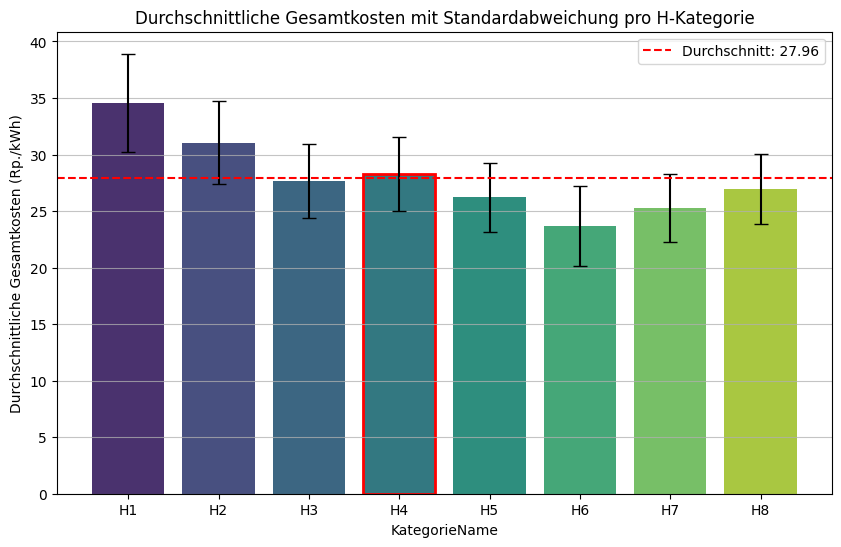

In [ ]:
#Durchschnittliche Gesamtkosten mit Standardabweichung pro H-Kategorie
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sicherstellen, dass df_filtered_H definiert ist (kopiert aus Zelle 1uZAcz8SLoIL und 28d9bd0f)
# Angenommen, 'df' ist bereits geladen, wie es im Kernel-Status der Fall ist.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[~df['kategorieName'].str.startswith('C')]

# Liste der numerischen Spalten (kopiert aus Zelle 1uZAcz8SLoIL)
num_cols = ['total', 'energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen']

# Gruppieren nach 'kategorieName' und statistische Beschreibung für die numerischen Spalten abrufen (kopiert aus Zelle 1uZAcz8SLoIL)
h_categories_comparison = df_filtered_H.groupby('kategorieName')[num_cols].describe()


# Extrahieren der mittleren Gesamtkosten und Standardabweichungen aus h_categories_comparison
mean_total_costs = h_categories_comparison['total']['mean']
std_total_costs = h_categories_comparison['total']['std']

# Erstellen eines DataFrames für die Visualisierung
plot_data = pd.DataFrame({
    'kategorieName': mean_total_costs.index,
    'mean_total': mean_total_costs.values,
    'std_total': std_total_costs.values
})

# Sortieren nach 'kategorieName' für konsistente Darstellung
plot_data = plot_data.sort_values(by='kategorieName')

plt.figure(figsize=(10, 6))
# Fix: Palette mit hue zuweisen, um Warnungen zu vermeiden
ax = sns.barplot(x='kategorieName', y='mean_total', data=plot_data, hue='kategorieName', palette='viridis', legend=False)

# Fehlerbalken manuell hinzufügen, um den Shape-Fehler zu umgehen
plt.errorbar(x=range(len(plot_data)), y=plot_data['mean_total'], yerr=plot_data['std_total'], fmt='none', c='black', capsize=5)

# Setze die Umrandungsfarbe für den H4-Balken
h4_index = plot_data[plot_data['kategorieName'] == 'H4'].index[0]
ax.patches[h4_index].set_edgecolor('red')
ax.patches[h4_index].set_linewidth(2)

# Eine Durchschnittslinie über alle Kategorien hinzufügen
overall_mean = plot_data['mean_total'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Durchschnitt: {overall_mean:.2f}')
plt.legend()

plt.title('Durchschnittliche Gesamtkosten mit Standardabweichung pro H-Kategorie')
plt.xlabel('KategorieName')
plt.ylabel('Durchschnittliche Gesamtkosten (Rp./kWh)')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Verteilung der Gesamtkosten in H-Kategorien
Das Histogramm zeigt, dass die Gesamtkosten (Rp./kWh) für Haushaltskategorien (H1-H8) eine leicht rechtsschiefe Verteilung aufweisen, mit einem Grossteil der Werte zwischen 20 und 35 Rp./kWh. Dies deutet darauf hin, dass die meisten Haushalte in diesem Kostenbereich liegen. Es gibt jedoch auch einige Ausreisser mit deutlich höheren Kosten, die für die Analyse von besonderem Interesse sein könnten, da eine Photovoltaikanlage dort eine grössere Einsparung ermöglichen würde.

Im Anhang werden alle H-Kategorien einzeln geplottet für eine bessere Übersicht.

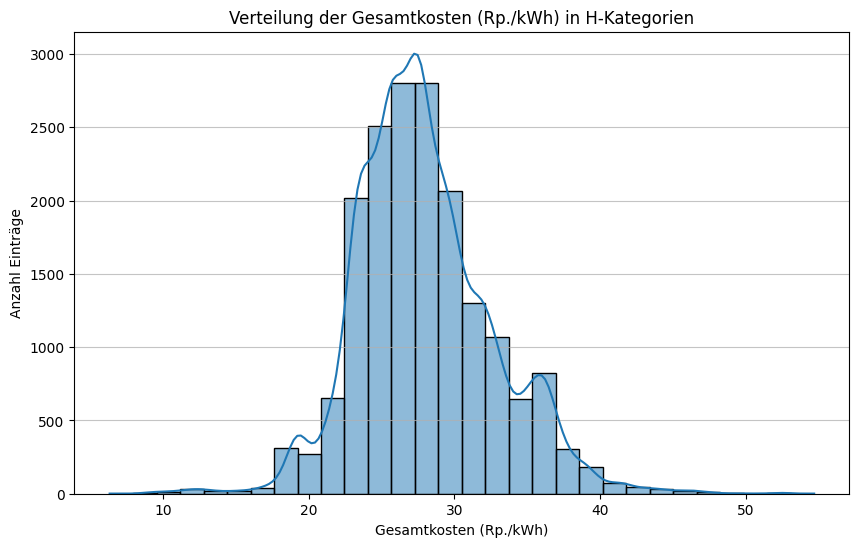

In [ ]:
#Verteilung der Gesamtkosten in H-Kategorien
import matplotlib.pyplot as plt
import seaborn as sns

# Sicherstellen, dass df_filtered_H definiert ist
# Filtern des DataFrames, um alle Einträge mit KategorieNamen, die mit 'C' beginnen, auszuschliessen.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[~df['kategorieName'].str.startswith('C')]

# Histogramm der Gesamtkosten für H-Kategorien
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered_H['total'], kde=True, bins=30)
plt.title('Verteilung der Gesamtkosten (Rp./kWh) in H-Kategorien')
plt.xlabel('Gesamtkosten (Rp./kWh)')
plt.ylabel('Anzahl Einträge')
plt.grid(axis='y', alpha=0.75)
plt.show()

#3 Datentransformation

Begrenzung auf die relevanten Spalten: netzbetreiber, gemeindeNummer, Kanton, Total & KategorieName

In [ ]:
selected_columns = ['netzbetreiber', 'gemeindeNummer', 'gemeindeName', 'kanton', 'total', 'kategorieName']
df_selected = df[selected_columns].copy()
display(df_selected.head())

,netzbetreiber,gemeindeNummer,gemeindeName,kanton,total,kategorieName
0,AEW Energie AG,4172,Münchwilen (AG),AG,26.594,C1
1,AEW Energie AG,4253,Magden,AG,26.594,C1
2,AEW Energie AG,4106,Mönthal,AG,26.555,C1
3,AEW Energie AG,4068,Hägglingen,AG,26.594,C1
4,AEW Energie AG,4258,Rheinfelden,AG,26.594,C1


Begrenzung auf die KategorieName H4:

In [ ]:
df_h4_only = df_selected[df_selected['kategorieName'] == 'H4'].copy()
display(df_h4_only.head())

,netzbetreiber,gemeindeNummer,gemeindeName,kanton,total,kategorieName
750,AEW Energie AG,4304,Döttingen,AG,27.780,H4
751,AEW Energie AG,4164,Gansingen,AG,27.892,H4
752,AEW Energie AG,4077,Tägerig,AG,27.892,H4
753,AEW Energie AG,4161,Eiken,AG,27.892,H4
754,AEW Energie AG,4163,Frick,AG,27.892,H4


In [ ]:
df_h4_only = df_h4_only.drop(columns=['kategorieName'])
display(df_h4_only.head())

,netzbetreiber,gemeindeNummer,gemeindeName,kanton,total
750,AEW Energie AG,4304,Döttingen,AG,27.780
751,AEW Energie AG,4164,Gansingen,AG,27.892
752,AEW Energie AG,4077,Tägerig,AG,27.892
753,AEW Energie AG,4161,Eiken,AG,27.892
754,AEW Energie AG,4163,Frick,AG,27.892


Max Wert der Netzbetreiber

In [ ]:
# Zählen Sie die Anzahl der Netzbetreiber pro Gemeinde
netzbetreiber_counts = df_h4_only.groupby('gemeindeNummer')['netzbetreiber'].nunique().reset_index()

# Gemeinden mit mehr als einem Netzbetreiber identifizieren
multiple_nb_gemeinden = netzbetreiber_counts[netzbetreiber_counts['netzbetreiber'] > 1]['gemeindeNummer']

# DataFrame für Gemeinden mit mehreren Netzbetreibern filtern
df_multiple_nb = df_h4_only[df_h4_only['gemeindeNummer'].isin(multiple_nb_gemeinden)].copy()

# Für Gemeinden mit mehreren Netzbetreibern den Netzbetreiber mit dem maximalen 'total'-Wert auswählen
# Hierbei wird die gesamte Zeile behalten, die den maximalen 'total'-Wert für jede Gemeinde repräsentiert
max_total_nb_for_multiple = df_multiple_nb.loc[df_multiple_nb.groupby('gemeindeNummer')['total'].idxmax()]

# DataFrame für Gemeinden mit nur einem Netzbetreiber filtern
single_nb_gemeinden = netzbetreiber_counts[netzbetreiber_counts['netzbetreiber'] == 1]['gemeindeNummer']
df_single_nb = df_h4_only[df_h4_only['gemeindeNummer'].isin(single_nb_gemeinden)].copy()

# Die beiden DataFrames zusammenführen
df_h4_processed = pd.concat([max_total_nb_for_multiple, df_single_nb]).sort_values(by='gemeindeNummer').reset_index(drop=True)

display(df_h4_processed.head())

,netzbetreiber,gemeindeNummer,gemeindeName,kanton,total
0,Elektrizitätswerke des Kantons Zürich (EKZ),1,Aeugst am Albis,ZH,24.136
1,Elektrizitätswerke des Kantons Zürich (EKZ),2,Affoltern am Albis,ZH,24.136
2,Elektrizitätswerke des Kantons Zürich (EKZ),3,Bonstetten,ZH,24.136
3,Elektrizitätswerke des Kantons Zürich (EKZ),4,Hausen am Albis,ZH,24.136
4,Elektrizitätswerke des Kantons Zürich (EKZ),5,Hedingen,ZH,24.136


In [ ]:
df_h4_processed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   netzbetreiber   2123 non-null   object 
 1   gemeindeNummer  2123 non-null   int64  
 2   gemeindeName    2123 non-null   object 
 3   kanton          2123 non-null   object 
 4   total           2123 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 83.1+ KB


In [ ]:
# Anzahl Netzbetreiber pro Gemeinde berechnen
netzbetreiber_pro_gemeinde = (
    df_h4_processed.groupby('gemeindeNummer')['netzbetreiber']
    .nunique()
)

# Durchschnitt berechnen
durchschnitt = netzbetreiber_pro_gemeinde.mean()

print("Durchschnittliche Anzahl Netzbetreiber pro Gemeinde:", durchschnitt)

Durchschnittliche Anzahl Netzbetreiber pro Gemeinde: 1.0


In [ ]:
df_h4_processed[df_h4_processed['total'] == 0.0]

,netzbetreiber,gemeindeNummer,gemeindeName,kanton,total


#4 Datenexport

In [61]:
output_path = 'df_h4_processed.csv'
df_h4_processed.to_csv(output_path, index=False)
print(f"'df_h4_processed' wurde erfolgreich als '{output_path}' gespeichert.")

'df_h4_processed' wurde erfolgreich als 'df_h4_processed.csv' gespeichert.


In [ ]:
import os
from google.colab import files

output_filename = 'df_h4_processed.csv'

# Eine Sitzungs-Flag initialisieren. Diese wird zurückgesetzt, wenn die Runtime neu gestartet wird.
if 'download_done_df_h4_processed' not in globals():
    download_done_df_h4_processed = False

# Nur herunterladen, wenn in dieser Sitzung noch nicht geschehen
if not download_done_df_h4_processed:
    if not os.path.exists(output_filename):
        files.download(output_filename)
        print(f'Datei \'{output_filename}\' wurde heruntergeladen.')
        download_done_df_h4_processed = True
    else:
        # Wenn die Datei existiert, markieren wir den Download für diese Sitzung als erledigt.
        # Dies deckt den Fall ab, dass die Datei von einer früheren Ausführung persistiert.
        print(f'Datei \'{output_filename}\' existiert bereits lokal. Kein erneuter Download in dieser Sitzung.')
        download_done_df_h4_processed = True
else:
    print(f'Datei \'{output_filename}\' wurde bereits in dieser Sitzung heruntergeladen. Kein erneuter Download.')

Datei 'df_h4_processed.csv' existiert bereits lokal. Kein erneuter Download in dieser Sitzung.


#5 Anhang

## Numerische Analyse

### Verteilung der Gesamtkosten ('total') in den H-Kategorien

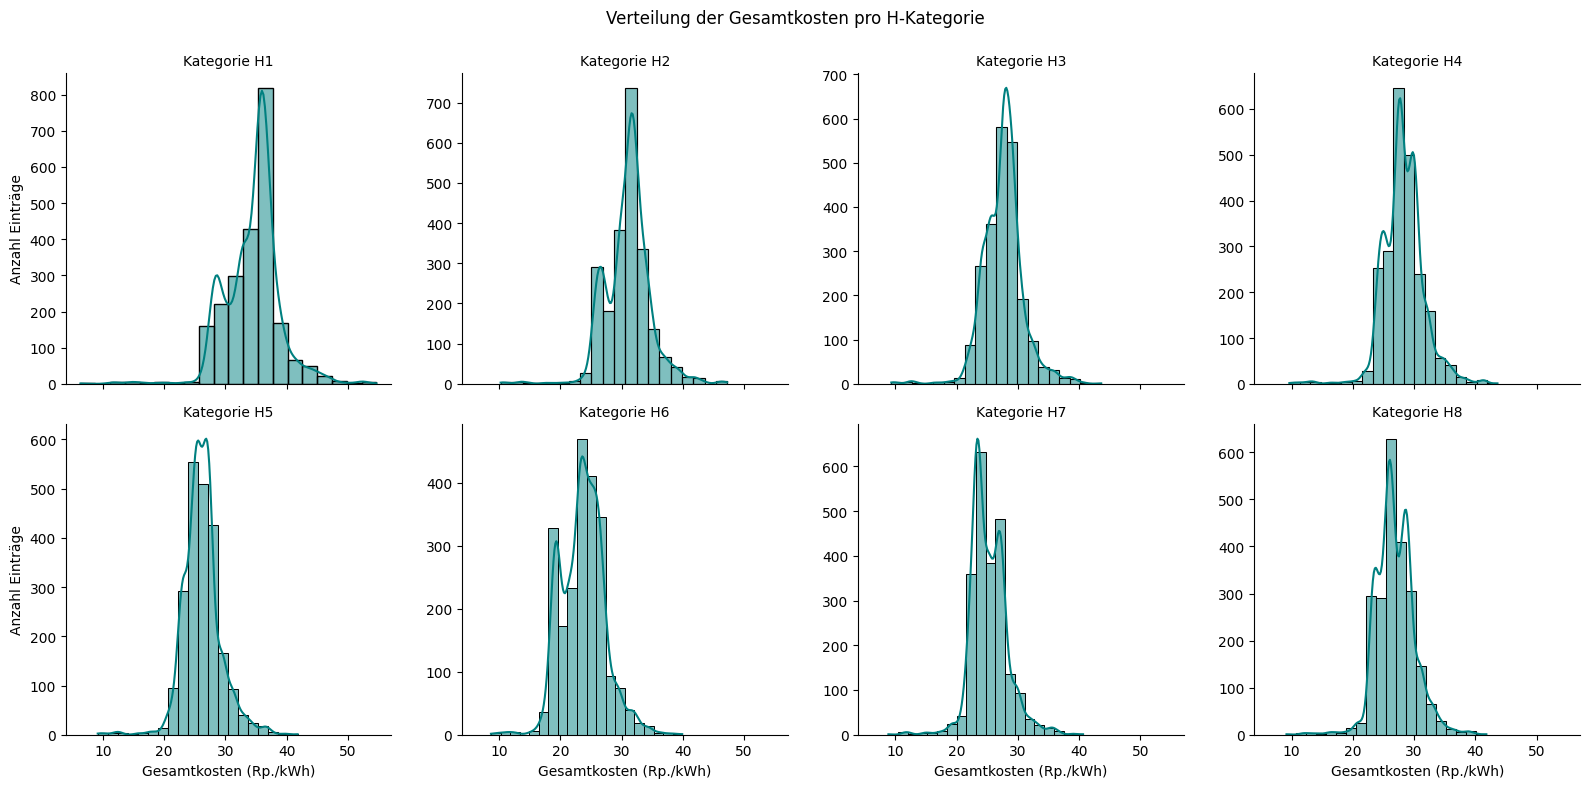

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sicherstellen, dass df_filtered_H definiert ist
# Filtert den DataFrame, um alle Einträge mit KategorieNamen, die mit 'C' beginnen, auszuschliessen.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[df['kategorieName'].str.startswith('H')]

# Facettierte Histogramme für jede Kategorie einzeln
g = sns.FacetGrid(df_filtered_H, col="kategorieName", col_wrap=4, height=4, sharex=True, sharey=False)
g.map(sns.histplot, "total", kde=True, bins=20, color='teal')

g.set_axis_labels("Gesamtkosten (Rp./kWh)", "Anzahl Einträge")
g.set_titles("Kategorie {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Verteilung der Gesamtkosten pro H-Kategorie')

plt.show()

### Deskriptive Tabelle der einzelnen H-Kategorien.

In [ ]:
import pandas as pd
import os

# Sicherstellen, dass der Datensatz 'df' existiert
if 'df' not in locals():
    path = '/content/drive/My Drive/BINA_PV_01/Rohdaten-Tarife-Standard-Produkt.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
    else:
        print("Fehler: Die Datei konnte nicht gefunden werden. Bitte führen Sie zuerst die Zelle zum Einlesen der CSV-Datei aus.")

if 'df' in locals():
    # Sicherstellen, dass nur Haushaltskategorien betrachtet werden
    h_kategorien = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8']
    df_h_only = df[df['kategorieName'].isin(h_kategorien)]

    # Relevante numerische Spalten auswählen
    num_cols = ['total', 'energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen']

    # Gruppieren nach Kategorie und Statistiken berechnen
    stats_comparison = df_h_only.groupby('kategorieName')[num_cols].describe()

    # Anzeige der Statistiken für 'total' als Übersicht
    print("Durchschnittswerte (Mean) pro Kategorie:")
    display(stats_comparison.xs('mean', level=1, axis=1))

    # Volle Statistiken anzeigen
    print("\nDetaillierte Statistiken:")
    display(stats_comparison)

Durchschnittswerte (Mean) pro Kategorie:


,total,energie,abgaben,netznutzung,netzzuschlag,messwesen
kategorieName,,,,,,
H1,34.553505,12.940587,0.927198,13.934196,2.294920,71.304011
H2,31.036697,12.610360,0.903380,12.377341,2.294914,71.268589
H3,27.655964,12.075872,0.880331,10.820941,2.294914,71.271243
H4,28.286124,12.356219,0.883730,11.164475,2.294786,71.404454
H5,26.201429,11.979110,0.838920,10.136756,2.293905,71.463551
H6,23.703072,11.607637,0.787007,8.722118,2.294907,72.852471
H7,25.282241,11.989971,0.810320,9.557677,2.294909,81.795680
H8,26.938691,12.246291,0.874868,10.560201,2.293880,72.267086



Detaillierte Statistiken:


total                                                  \
                count       mean       std     min       25%      50%   
kategorieName                                                           
H1             2264.0  34.553505  4.359854   6.355  32.54800  35.3785   
H2             2261.0  31.036697  3.663362  10.260  29.41800  31.5000   
H3             2261.0  27.655964  3.234351   9.353  25.56500  27.6960   
H4             2263.0  28.286124  3.261599   9.643  26.27700  27.8920   
H5             2264.0  26.201429  3.068769   9.174  24.64800  25.9930   
H6             2258.0  23.703072  3.530465   8.681  21.50275  23.5630   
H7             2259.0  25.282241  3.004146   8.876  23.23900  25.1030   
H8             2255.0  26.938691  3.126194   9.174  24.93650  26.5800   

                               energie             ... netzzuschlag       \
                   75%     max   count       mean  ...          75%  max   
kategorieName                                      ...                     
H1             36.5150  54.669  2264.0  12.940587  ...          2.3  2.3   
H2             32.9000  47.240  2261.0  12.610360  ...          2.3  2.3   
H3             29.2590  43.613  2261.0  12.075872  ...          2.3  2.3   
H4             30.0160  43.613  2263.0  12.356219  ...          2.3  2.3   
H5             27.4040  41.800  2264.0  11.979110  ...          2.3  2.3   
H6             26.1660  39.896  2258.0  11.607637  ...          2.3  2.3   
H7             27.1400  40.649  2259.0  11.989971  ...          2.3  2.3   
H8             28.8225  41.800  2255.0  12.246291  ...          2.3  2.3   

              messwesen                                                       
                  count       mean        std  min   25%   50%    75%    max  
kategorieName                                                                 
H1               2264.0  71.304011  15.346988  0.0  60.0  74.4  79.32  180.0  
H2               2261.0  71.268589  15.318154  0.0  60.0  74.4  79.32  180.0  
H3               2261.0  71.271243  15.318280  0.0  60.0  74.4  79.32  180.0  
H4               2263.0  71.404454  15.426998  0.0  60.0  74.4  79.32  180.0  
H5               2264.0  71.463551  15.405300  0.0  60.0  74.4  79.32  180.0  
H6               2258.0  72.852471  19.028301  0.0  60.0  74.4  79.32  192.0  
H7               2259.0  81.795680  31.285355  0.0  69.6  79.0  82.80  641.4  
H8               2255.0  72.267086  22.127728  0.0  60.0  74.4  79.32  384.0  

[8 rows x 48 columns]

In [ ]:
import pandas as pd

# Sicherstellen, dass df_filtered_H definiert ist
# Filtert den DataFrame, um alle Einträge mit KategorieNamen, die mit 'C' beginnen, auszuschliessen.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[~df['kategorieName'].str.startswith('C')]

# Liste der numerischen Spalten
num_cols = ['total', 'energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen']

# Gruppieren nach 'kategorieName' und statistische Beschreibung für die numerischen Spalten abrufen
h_categories_comparison = df_filtered_H.groupby('kategorieName')[num_cols].describe()

# Das Ergebnis anzeigen
display(h_categories_comparison)

total                                                  \
                count       mean       std     min       25%      50%   
kategorieName                                                           
H1             2264.0  34.553505  4.359854   6.355  32.54800  35.3785   
H2             2261.0  31.036697  3.663362  10.260  29.41800  31.5000   
H3             2261.0  27.655964  3.234351   9.353  25.56500  27.6960   
H4             2263.0  28.286124  3.261599   9.643  26.27700  27.8920   
H5             2264.0  26.201429  3.068769   9.174  24.64800  25.9930   
H6             2258.0  23.703072  3.530465   8.681  21.50275  23.5630   
H7             2259.0  25.282241  3.004146   8.876  23.23900  25.1030   
H8             2255.0  26.938691  3.126194   9.174  24.93650  26.5800   

                               energie             ... netzzuschlag       \
                   75%     max   count       mean  ...          75%  max   
kategorieName                                      ...                     
H1             36.5150  54.669  2264.0  12.940587  ...          2.3  2.3   
H2             32.9000  47.240  2261.0  12.610360  ...          2.3  2.3   
H3             29.2590  43.613  2261.0  12.075872  ...          2.3  2.3   
H4             30.0160  43.613  2263.0  12.356219  ...          2.3  2.3   
H5             27.4040  41.800  2264.0  11.979110  ...          2.3  2.3   
H6             26.1660  39.896  2258.0  11.607637  ...          2.3  2.3   
H7             27.1400  40.649  2259.0  11.989971  ...          2.3  2.3   
H8             28.8225  41.800  2255.0  12.246291  ...          2.3  2.3   

              messwesen                                                       
                  count       mean        std  min   25%   50%    75%    max  
kategorieName                                                                 
H1               2264.0  71.304011  15.346988  0.0  60.0  74.4  79.32  180.0  
H2               2261.0  71.268589  15.318154  0.0  60.0  74.4  79.32  180.0  
H3               2261.0  71.271243  15.318280  0.0  60.0  74.4  79.32  180.0  
H4               2263.0  71.404454  15.426998  0.0  60.0  74.4  79.32  180.0  
H5               2264.0  71.463551  15.405300  0.0  60.0  74.4  79.32  180.0  
H6               2258.0  72.852471  19.028301  0.0  60.0  74.4  79.32  192.0  
H7               2259.0  81.795680  31.285355  0.0  69.6  79.0  82.80  641.4  
H8               2255.0  72.267086  22.127728  0.0  60.0  74.4  79.32  384.0  

[8 rows x 48 columns]

### Durchschnittliche Aufschlüsselung der Kostenkomponenten nach H-Kategorie

Die Kategorie "Messwesen" wird teilweise nicht pro Kwh berechnet (sondern monatlich). Aufgrund dessen wird in der folgenden Grafik die Variable nicht ausgewiesen.

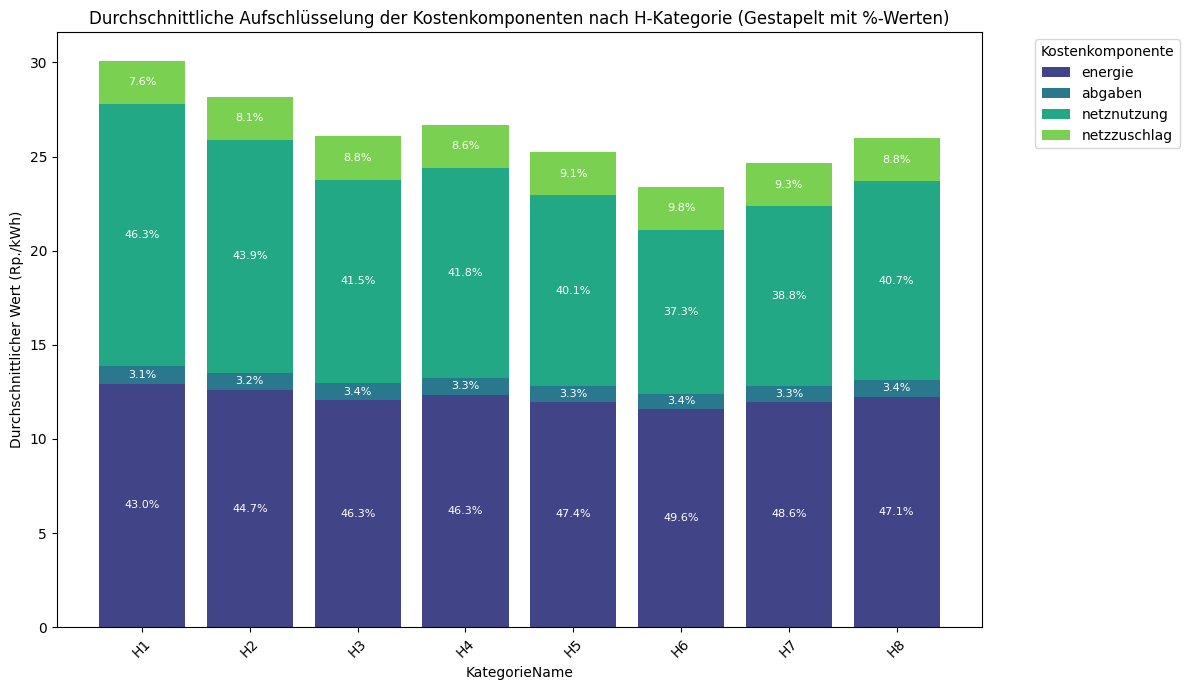

In [ ]:
# Sicherstellen, dass df_filtered_H definiert ist
# Filtert den DataFrame, um alle Einträge mit KategorieNamen, die mit 'C' beginnen, auszuschliessen.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[~df['kategorieName'].str.startswith('C')]

# Aggregieren der durchschnittlichen Kostenkomponenten pro H-Kategorie
cost_components_avg = df_filtered_H.groupby('kategorieName')[['energie', 'abgaben', 'netznutzung', 'netzzuschlag']].mean().reset_index()

# Setze 'kategorieName' als Index für einfacheres Plotten
cost_components_pivot = cost_components_avg.set_index('kategorieName')

# Definiere die zu stapelnden Spalten
components = ['energie', 'abgaben', 'netznutzung', 'netzzuschlag']

# Berechne die Summe für jede Kategorie, um für Prozentsätze zu normalisieren
cost_components_pivot['total_sum'] = cost_components_pivot[components].sum(axis=1)

plt.figure(figsize=(12, 7))


# Genügend Farben erhalten
colors = sns.color_palette('viridis', n_colors=len(components))

# Initialisiere 'bottom' für das Stapeln
bottom = [0] * len(cost_components_pivot)

for i, comp in enumerate(components):
    plt.bar(cost_components_pivot.index, cost_components_pivot[comp], bottom=bottom, label=comp, color=colors[i])

    # Prozentsatz-Beschriftungen hinzufügen
    for j, (category, value) in enumerate(cost_components_pivot[comp].items()):
        total_for_category = cost_components_pivot.loc[category, 'total_sum']
        percentage = (value / total_for_category) * 100 if total_for_category > 0 else 0

        # Positioniere den Text leicht über dem unteren Rand des aktuellen Balkensegments
        # und zentriere ihn horizontal auf dem Balken
        plt.text(j, bottom[j] + value / 2, f'{percentage:.1f}%',
                 ha='center', va='center', color='white', fontsize=8)

    # 'bottom' für die nächste Komponente aktualisieren
    bottom = [sum(x) for x in zip(bottom, cost_components_pivot[comp])]

plt.title('Durchschnittliche Aufschlüsselung der Kostenkomponenten nach H-Kategorie (Gestapelt mit %-Werten)')
plt.xlabel('KategorieName')
plt.ylabel('Durchschnittlicher Wert (Rp./kWh)')
plt.xticks(rotation=45)
plt.legend(title='Kostenkomponente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Erkenntnisse aus dem Vergleich der Gesamtkosten zwischen den einzelnen H-Kategorien:
Das Boxplot visualisiert die Verteilung der Gesamtkosten für jede einzelne H-Kategorie. Es zeigt den Median, die Quartile und potenzielle Ausreisser. Wir können hier sehen, ob es signifikante Unterschiede in den Gesamtkosten zwischen den verschiedenen Haushaltskategorien gibt. Beispielsweise könnten H1-Kategorien (kleinster Verbrauch) höhere Kosten pro kWh haben als H8-Kategorien (grösster Verbrauch) aufgrund von Fixkostenanteilen oder umgekehrt. Ausreisser (Punkte ausserhalb der Whisker) deuten auf ungewöhnlich hohe oder niedrige Kosten für bestimmte Einträge in einer Kategorie hin. Dies ist wichtig für die Identifizierung von Segmenten, in denen eine PV-Anlage besonders rentabel sein könnte.

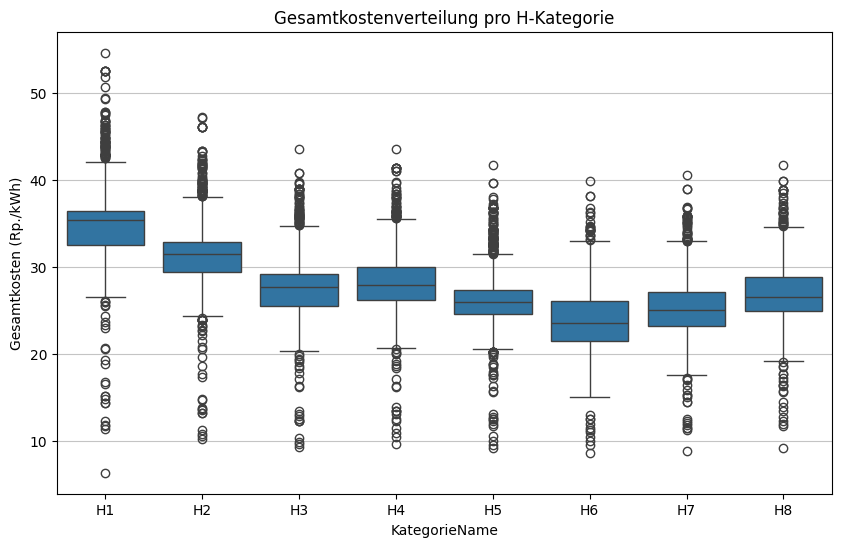

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='kategorieName', y='total', data=df_filtered_H, order=sorted(df_filtered_H['kategorieName'].unique()))
plt.title('Gesamtkostenverteilung pro H-Kategorie')
plt.xlabel('KategorieName')
plt.ylabel('Gesamtkosten (Rp./kWh)')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Gesamtverteilung pro Kanton

Boxplot: Gesamtkostenverteilung pro Kanton Dieser Boxplot zeigt die Verteilung der Gesamtkosten pro Kanton, sortiert nach dem Median. Kantone wie BS und SH weisen tendenziell höhere Mediankosten auf, während ZG und NW niedrigere Mediankosten zeigen. Die Länge der Boxen und Whisker gibt Aufschluss über die Variabilität der Kosten innerhalb jedes Kantons.

Bubble Chart: Kantone nach Median, Standardabweichung und Anzahl der Einträge Das Bubble Chart stellt die Kantone basierend auf ihren medianen Gesamtkosten, der Standardabweichung (als Mass für die Variabilität) und der Anzahl der Datenpunkte (Grösse der Blase) dar. Es hilft, Kantone mit hohen Kosten und hoher Variabilität schnell zu identifizieren, was auf eine heterogene Kostenstruktur hindeutet, oder Kantone mit vielen Datenpunkten, die eine robustere Analyse ermöglichen.

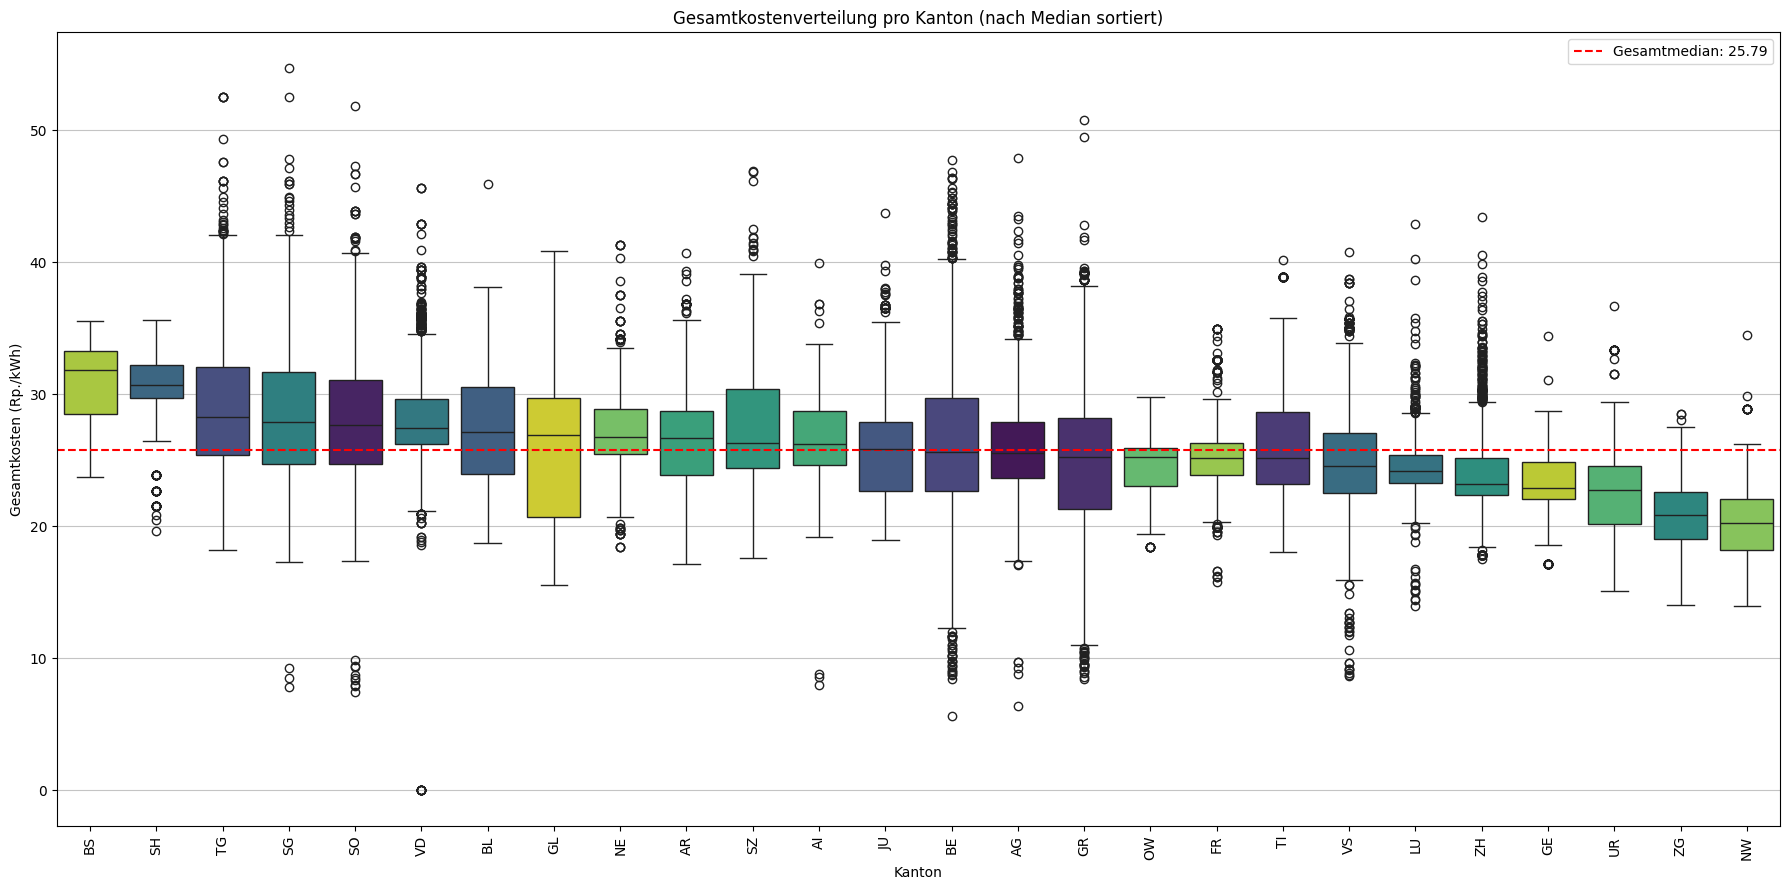

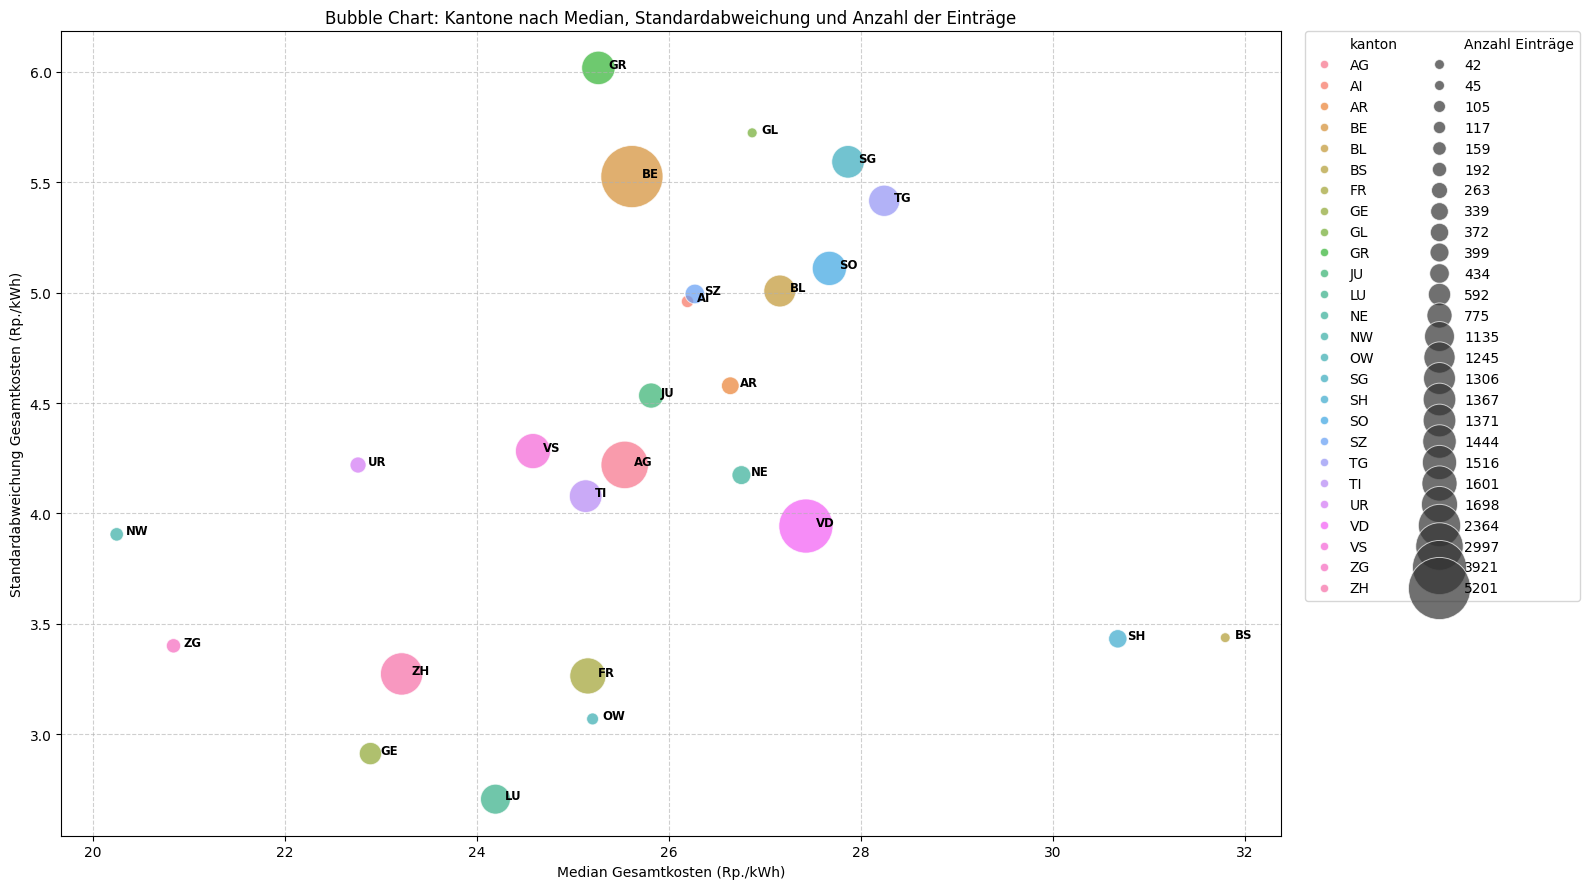

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Boxplot --- #
median_total_per_kanton = df.groupby('kanton')['total'].median().sort_values(ascending=False)
ordered_cantons = median_total_per_kanton.index

plt.figure(figsize=(18, 9))
sns.boxplot(x='kanton', y='total', data=df, order=ordered_cantons, palette='viridis', hue='kanton', legend=False)
plt.title('Gesamtkostenverteilung pro Kanton (nach Median sortiert)')
plt.xlabel('Kanton')
plt.ylabel('Gesamtkosten (Rp./kWh)')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.75)

overall_median_total = df['total'].median()
plt.axhline(y=overall_median_total, color='red', linestyle='--', label=f'Gesamtmedian: {overall_median_total:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# --- Bubble Chart Optimierung --- # (Kommentar geändert)
kanton_bubble_data = df.groupby('kanton')['total'].agg(['median', 'std', 'count']).reset_index()
kanton_bubble_data = kanton_bubble_data.rename(columns={'median': 'Median Gesamtkosten', 'std': 'Standardabweichung Gesamtkosten', 'count': 'Anzahl Einträge'})

plt.figure(figsize=(16, 9))
scatter = sns.scatterplot(
    data=kanton_bubble_data,
    x='Median Gesamtkosten',
    y='Standardabweichung Gesamtkosten',
    size='Anzahl Einträge',
    hue='kanton',
    sizes=(50, 2000),
    alpha=0.7,
    legend='full'
)

# Legende ausserhalb des Diagramms platzieren
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=2)

for i, row in kanton_bubble_data.iterrows():
    plt.text(row['Median Gesamtkosten'] + 0.1, row['Standardabweichung Gesamtkosten'], row['kanton'],
             horizontalalignment='left', size='small', color='black', weight='semibold')

plt.title('Bubble Chart: Kantone nach Median, Standardabweichung und Anzahl der Einträge')
plt.xlabel('Median Gesamtkosten (Rp./kWh)')
plt.ylabel('Standardabweichung Gesamtkosten (Rp./kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
kanton_stats = df.groupby('kanton')['total'].describe()
print("Kanton mit der höchsten Standardabweichung:")
display(kanton_stats.sort_values(by='std', ascending=False))

Kanton mit der höchsten Standardabweichung:


,count,mean,std,min,25%,50%,75%,max
kanton,,,,,,,,
GR,1444.0,24.793011,6.017639,8.399,21.27200,25.2660,28.16700,50.743
GL,45.0,25.795111,5.723484,15.542,20.70900,26.8680,29.72000,40.830
SG,1367.0,28.340907,5.592297,7.790,24.73150,27.8670,31.69100,54.669
BE,5201.0,26.306907,5.525484,5.620,22.68400,25.6150,29.71000,47.755
TG,1245.0,29.061991,5.415916,18.184,25.39000,28.2440,32.06300,52.537
SO,1516.0,27.995849,5.109636,7.391,24.66975,27.6725,31.10000,51.830
BL,1306.0,27.149384,5.007242,18.730,23.91100,27.1560,30.51100,45.908
SZ,434.0,27.605433,4.993835,17.570,24.39300,26.2710,30.38000,46.877
AI,117.0,26.391402,4.959775,7.969,24.64600,26.1940,28.74100,39.948


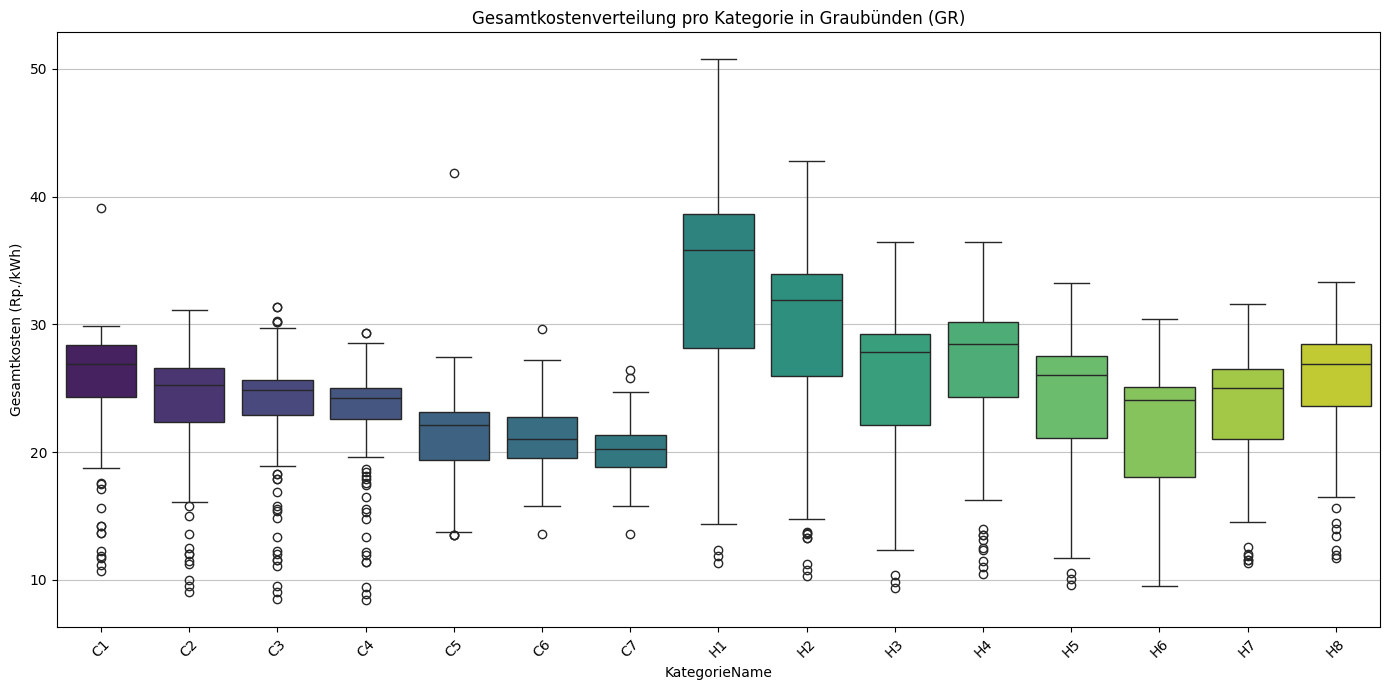

In [ ]:
df_gr = df[df['kanton'] == 'GR']

plt.figure(figsize=(14, 7))
sns.boxplot(x='kategorieName', y='total', data=df_gr, order=sorted(df_gr['kategorieName'].unique()), palette='viridis', hue='kategorieName', legend=False)
plt.title('Gesamtkostenverteilung pro Kategorie in Graubünden (GR)')
plt.xlabel('KategorieName')
plt.ylabel('Gesamtkosten (Rp./kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Multivariate Analyse

Nun werden wir die Beziehungen zwischen den Gesamtkosten ('total') und ihren einzelnen Komponenten ('energie', 'abgaben', 'netznutzung', 'netzzuschlag', 'messwesen') für die Haushaltskategorien (H-Kategorien) genauer untersuchen. Dies hilft uns, die Treiber der Gesamtkosten besser zu verstehen und potenzielle Muster oder Ausreisser zu identifizieren.

#### Streudiagramme der Kostenkomponenten vs. Gesamtkosten (H-Kategorien)

Die folgenden Streudiagramme zeigen die Korrelation jeder Kostenkomponente mit den Gesamtkosten. Eine klare lineare Beziehung deutet auf einen starken Einfluss hin, während eine diffuse Punktwolke auf eine geringere Korrelation schliessen lässt.

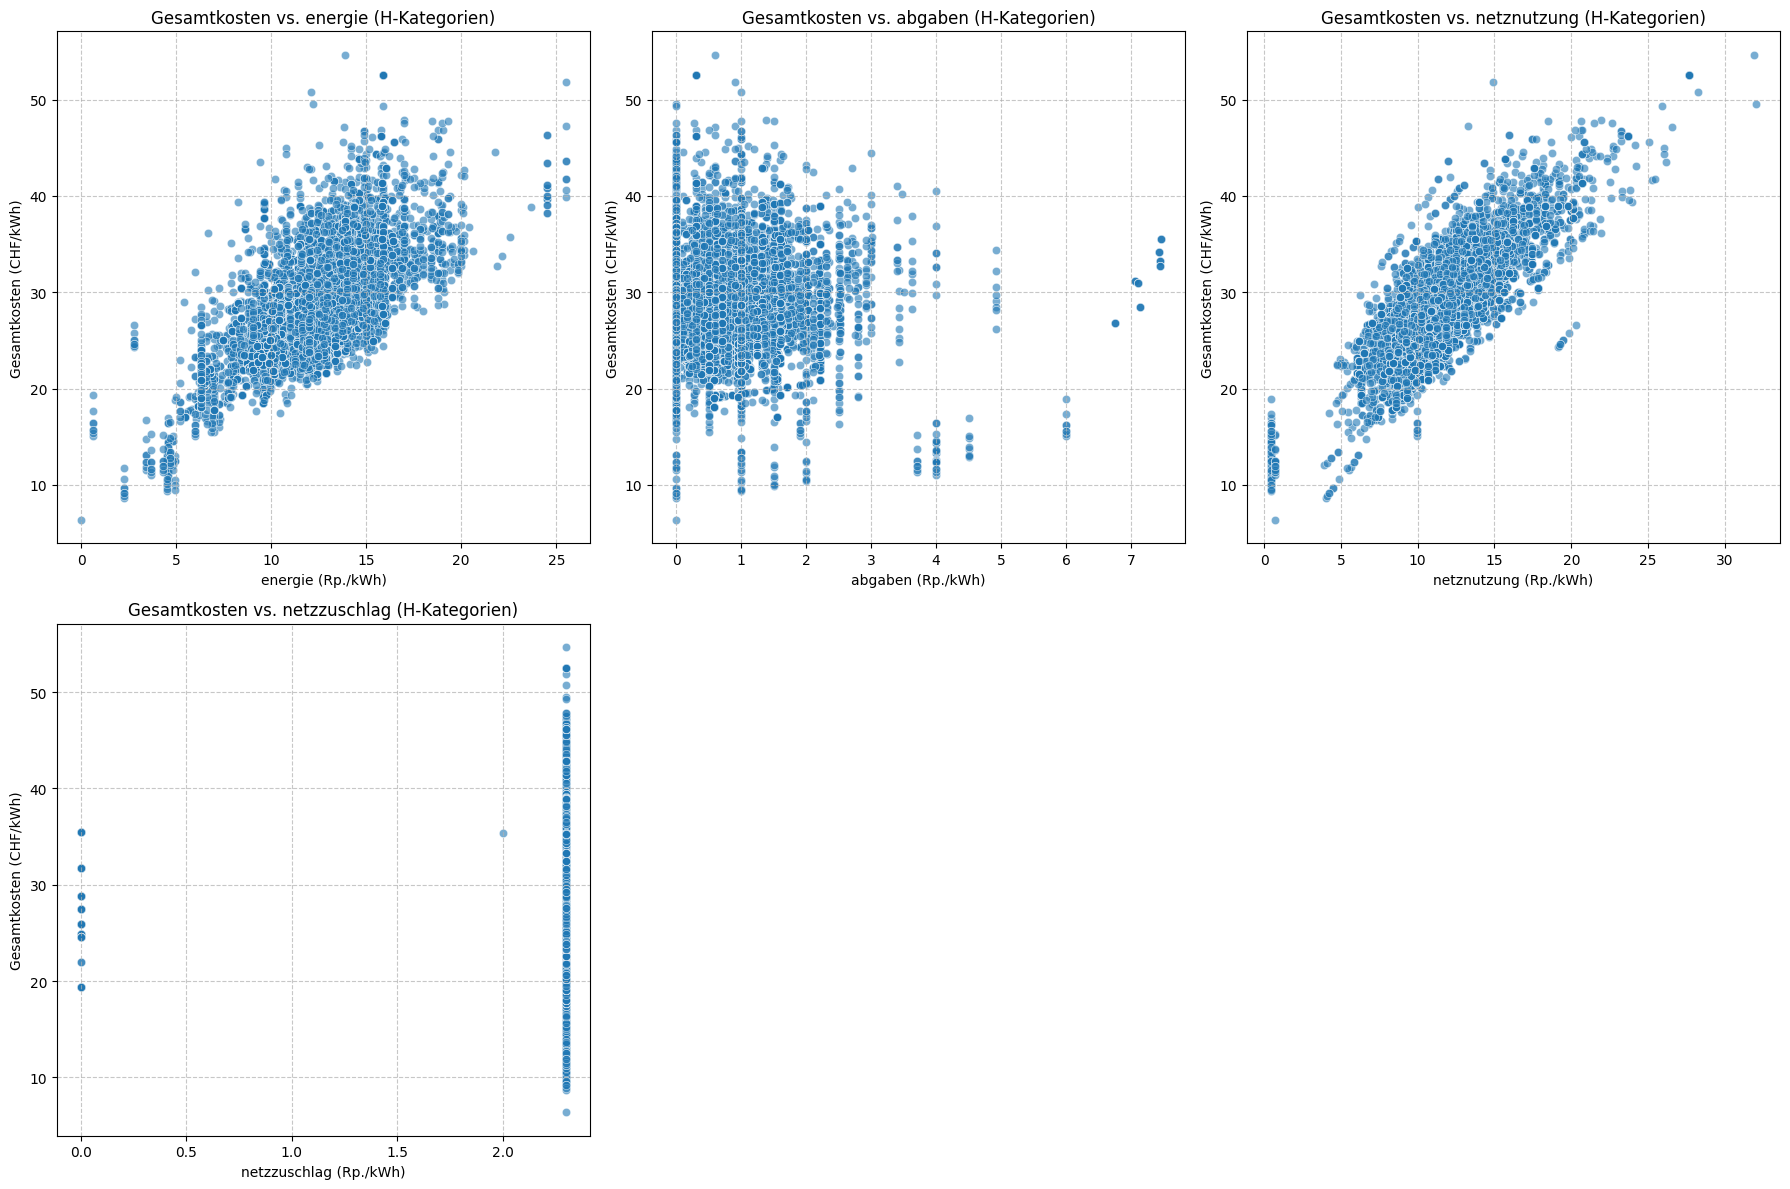

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sicherstellen, dass df_filtered_H definiert ist
# Dies ist wichtig, da der Kernel neu gestartet worden sein könnte oder die Zelle für df_filtered_H noch nicht ausgeführt wurde.
# df_filtered_H wurde bereits in früheren Schritten erstellt, filtert den DataFrame, um alle Einträge mit KategorieNamen, die mit 'C' beginnen, auszuschliessen.
if 'df_filtered_H' not in locals():
    df_filtered_H = df[~df['kategorieName'].str.startswith('C')]

# Liste der Kostenkomponenten
cost_components = ['energie', 'abgaben', 'netznutzung', 'netzzuschlag']

# Erstellen von Streudiagrammen für jede Kostenkomponente gegen 'total'
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cost_components):
    sns.scatterplot(x=col, y='total', data=df_filtered_H, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Gesamtkosten vs. {col} (H-Kategorien)')
    axes[i].set_xlabel(f'{col} (Rp./kWh)')
    axes[i].set_ylabel('Gesamtkosten (CHF/kWh)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Den letzten leeren Plot (falls vorhanden) entfernen
if len(cost_components) < len(axes):
    for j in range(len(cost_components), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Streudiagramm für H4

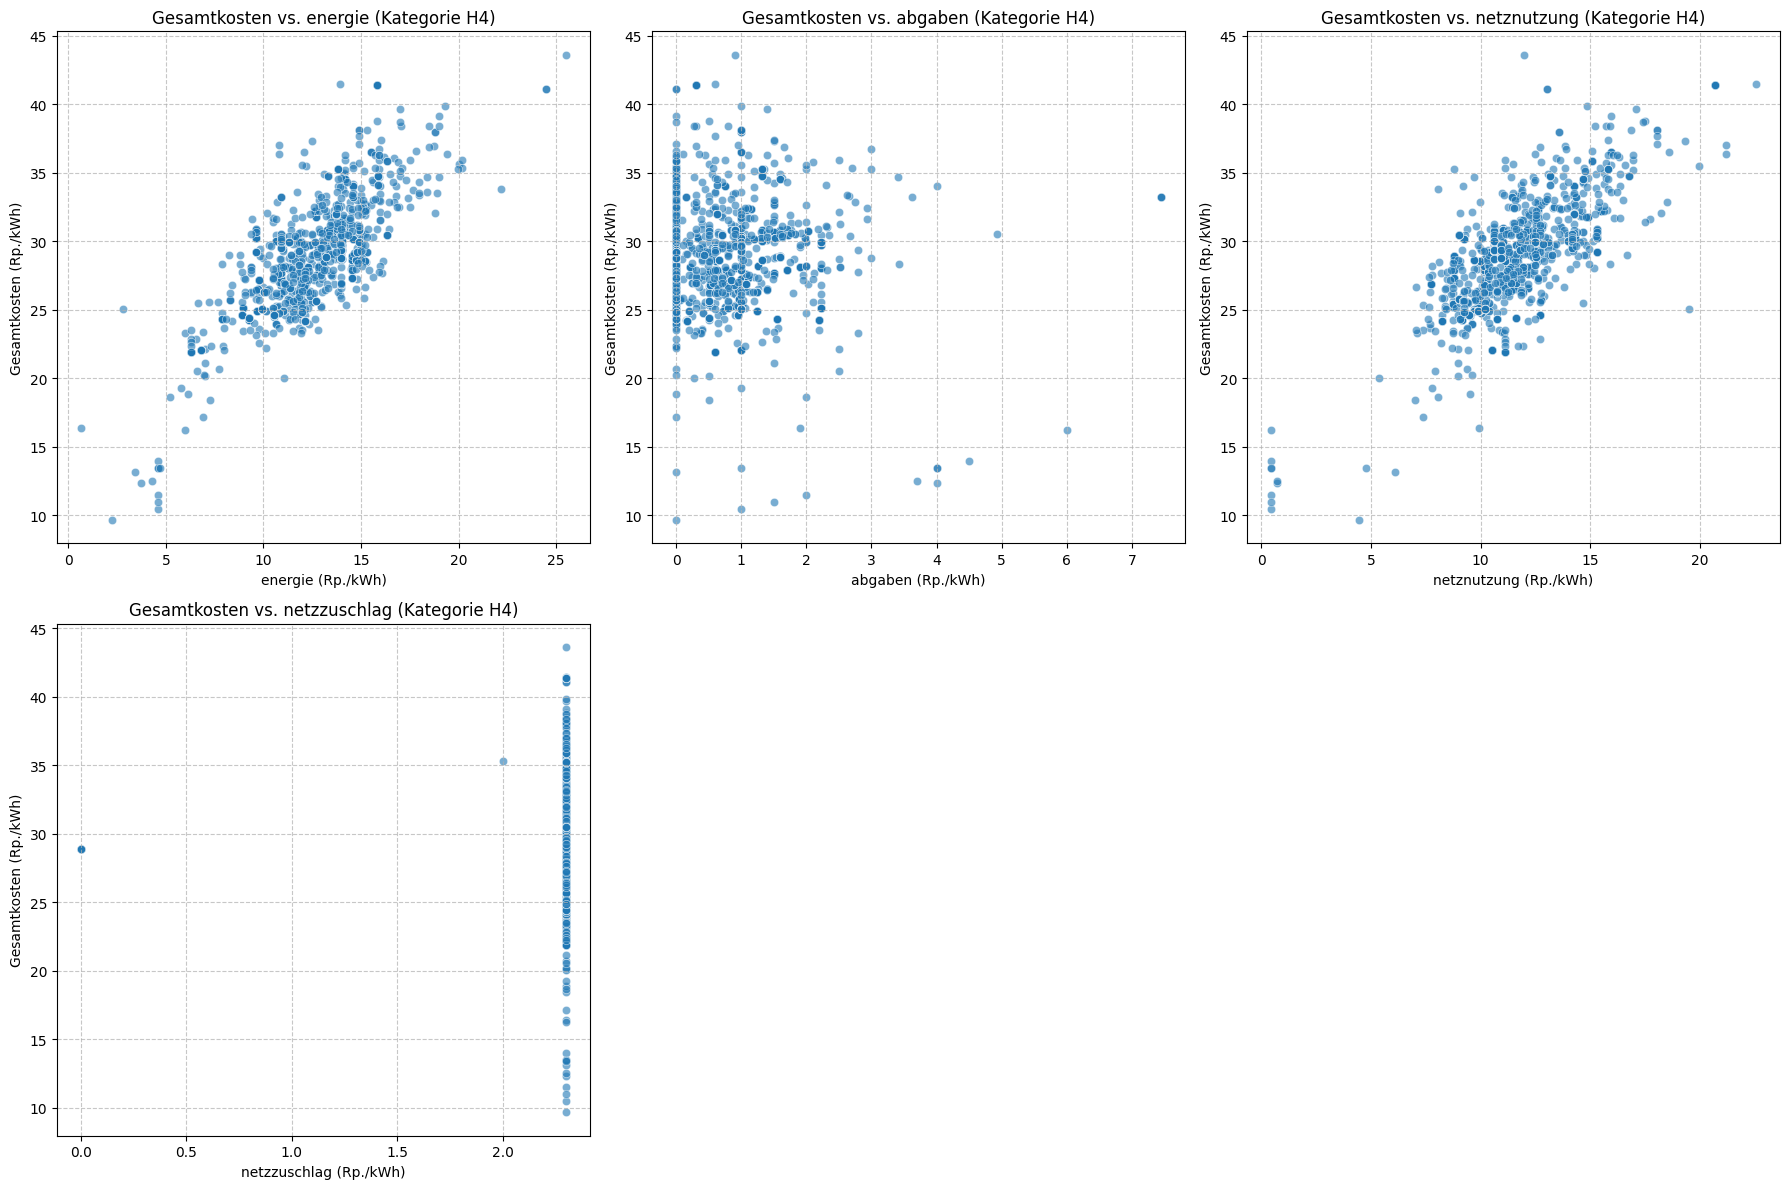

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtern des DataFrames auf die spezifische Kategorie 'H4'
df_h4 = df[df['kategorieName'] == 'H4']

# Liste der Kostenkomponenten
cost_components = ['energie', 'abgaben', 'netznutzung', 'netzzuschlag']

# Erstellen von Streudiagrammen für jede Kostenkomponente gegen 'total'
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cost_components):
    sns.scatterplot(x=col, y='total', data=df_h4, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Gesamtkosten vs. {col} (Kategorie H4)')
    axes[i].set_xlabel(f'{col} (Rp./kWh)')
    axes[i].set_ylabel('Gesamtkosten (Rp./kWh)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Den letzten leeren Plot (falls vorhanden) entfernen
if len(cost_components) < len(axes):
    for j in range(len(cost_components), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()